In [1]:
import pandas as pd

new_columns = [
    "timestamp",
    "gender",
    "high_school_gpa",
    "academic_year_2023",
    "faculty",
    "uni_gpa_2023",
    "accommodation_2023",
    "monthly_allowance_2023",
    "has_scholarship_2023",
    "weekly_study_hours",
    "socializing_frequency",
    "drinks_per_night",
    "missed_classes_alcohol",
    "failed_modules_total",
    "in_relationship",
    "parent_alcohol_approval",
    "parent_relationship_strength"
]

student_data = pd.read_csv("survey_student.csv", names= new_columns, header=0)
student_data.drop("timestamp", axis = 1, inplace = True)

student_data.head()

,gender,high_school_gpa,academic_year_2023,faculty,uni_gpa_2023,accommodation_2023,monthly_allowance_2023,has_scholarship_2023,weekly_study_hours,socializing_frequency,drinks_per_night,missed_classes_alcohol,failed_modules_total,in_relationship,parent_alcohol_approval,parent_relationship_strength
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


## Exploratory Data Analysis

In [2]:
student_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        404 non-null    str    
 1   high_school_gpa               399 non-null    float64
 2   academic_year_2023            333 non-null    str    
 3   faculty                       399 non-null    str    
 4   uni_gpa_2023                  320 non-null    float64
 5   accommodation_2023            383 non-null    str    
 6   monthly_allowance_2023        375 non-null    str    
 7   has_scholarship_2023          398 non-null    str    
 8   weekly_study_hours            403 non-null    str    
 9   socializing_frequency         404 non-null    str    
 10  drinks_per_night              404 non-null    str    
 11  missed_classes_alcohol        403 non-null    str    
 12  failed_modules_total          403 non-null    str    
 13  in_relationship 

In [3]:
student_data.isna().sum()

gender                           2
high_school_gpa                  7
academic_year_2023              73
faculty                          7
uni_gpa_2023                    86
accommodation_2023              23
monthly_allowance_2023          31
has_scholarship_2023             8
weekly_study_hours               3
socializing_frequency            2
drinks_per_night                 2
missed_classes_alcohol           3
failed_modules_total             3
in_relationship                  3
parent_alcohol_approval          4
parent_relationship_strength     3
dtype: int64

<Axes: xlabel='drinks_per_night'>

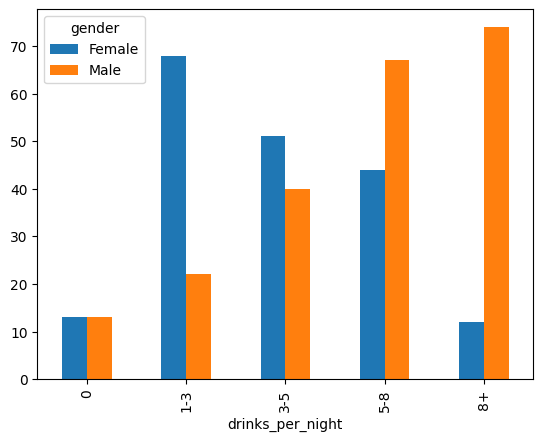

In [4]:
# Gender Specific Alcohal consumption

tabel = pd.crosstab(
    student_data.gender, 
    student_data.drinks_per_night
).T

tabel.plot(kind = "bar")

In [5]:
# Relation with parent and scored gained 

student_data.parent_relationship_strength.value_counts()

parent_relationship_strength
Very close    269
Close          97
Fair           35
Distant         2
Name: count, dtype: int64

In [6]:
groups = student_data.groupby(by = "parent_relationship_strength")

In [7]:
groups[["high_school_gpa", "uni_gpa_2023"]].aggregate(("min", "max", "median", "mean"))

high_school_gpa                           \
                                         min    max median       mean   
parent_relationship_strength                                            
Close                                   60.0  98.33   78.0  77.690000   
Distant                                 85.0  98.00   91.5  91.500000   
Fair                                    55.0  95.50   79.0  78.357143   
Very close                              34.0  99.00   78.0  77.960114   

                             uni_gpa_2023                           
                                      min    max median       mean  
parent_relationship_strength                                        
Close                                50.0  95.22   63.0  65.220769  
Distant                              88.0  89.00   88.5  88.500000  
Fair                                 50.0  85.00   66.0  66.258065  
Very close                           30.0  92.00   65.0  66.527356

In [8]:
# Relation with HS and uni grade
student_data.corr(numeric_only=True)

,high_school_gpa,uni_gpa_2023
high_school_gpa,1.000000,0.299104
uni_gpa_2023,0.299104,1.000000


<Axes: xlabel='high_school_gpa', ylabel='uni_gpa_2023'>

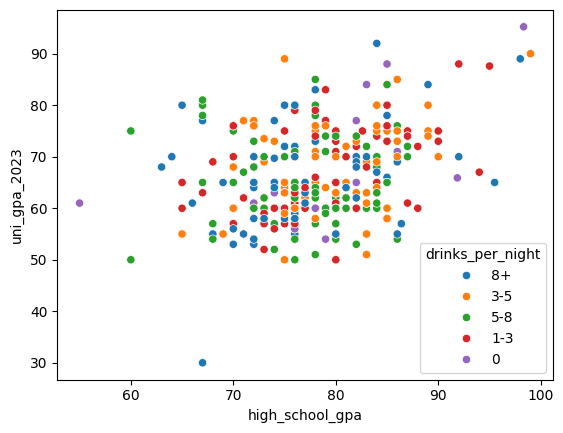

In [9]:
import seaborn as sns

sns.scatterplot(student_data, x = "high_school_gpa", y ="uni_gpa_2023", hue="drinks_per_night")

#### Manipulation / Cleaning / Transforming / Processing Data

* Data management
* Duplication
* Null Value Handling
* Outlier Handling
* Integration

* Encoding / Normalization / Post-processing

In [13]:
# Duplication
student_data[student_data.duplicated()]

,gender,high_school_gpa,academic_year_2023,faculty,uni_gpa_2023,accommodation_2023,monthly_allowance_2023,has_scholarship_2023,weekly_study_hours,socializing_frequency,drinks_per_night,missed_classes_alcohol,failed_modules_total,in_relationship,parent_alcohol_approval,parent_relationship_strength
144,Female,85.0,2nd Year,Economic & Management Sciences,73.0,Private accommodation/ stay with family/friends,R 5001 - R 6000,No,8+,2,1-3,4+,0,Yes,Yes,Very close
232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
325,Male,71.0,NaN,Economic & Management Sciences,NaN,Private accommodation/ stay with family/friends,R 4001- R 5000,"Yes (NSFAS, etc...)",3-5,2,8+,1,0,Yes,Yes,Very close


In [14]:
student_data.drop_duplicates(inplace=True)

In [16]:
# Counting Null Values
student_data.isna().sum()

gender                           1
high_school_gpa                  6
academic_year_2023              71
faculty                          6
uni_gpa_2023                    84
accommodation_2023              22
monthly_allowance_2023          30
has_scholarship_2023             7
weekly_study_hours               2
socializing_frequency            1
drinks_per_night                 1
missed_classes_alcohol           2
failed_modules_total             2
in_relationship                  2
parent_alcohol_approval          3
parent_relationship_strength     2
dtype: int64

In [17]:
# 1 . Removing
# 2 . Imputation 
# 3 . Feature Engineering [Null as a feature]

In [26]:
# student_data[student_data.isna().sum(axis = 1) > 8]

student_data_1 = student_data.dropna(thresh= 8)

In [45]:
null_counts = student_data_1.isna().sum()
null_counts

gender                           0
high_school_gpa                  5
academic_year_2023              70
faculty                          5
uni_gpa_2023                    83
accommodation_2023              21
monthly_allowance_2023          29
has_scholarship_2023             6
weekly_study_hours               1
socializing_frequency            0
drinks_per_night                 0
missed_classes_alcohol           1
failed_modules_total             1
in_relationship                  1
parent_alcohol_approval          2
parent_relationship_strength     1
dtype: int64

In [50]:
null_counts[(null_counts > 0) & (null_counts < 10)].index

Index(['high_school_gpa', 'faculty', 'has_scholarship_2023',
       'weekly_study_hours', 'missed_classes_alcohol', 'failed_modules_total',
       'in_relationship', 'parent_alcohol_approval',
       'parent_relationship_strength'],
      dtype='str')

In [41]:
def fill_with_mode(
    df : pd.DataFrame, 
    threshold: int = 10
)-> pd.DataFrame:
    """Function to imput any columns of dataframe with 
    mode , if total null values are less than threshold

    Parameters
    ----------
    df : pd.DataFrame
        Input Dataframe from user
    threshold : int, optional
        null value required to impute, by default 10

    Returns
    -------
    pd.DataFrame
        Output Dataframe with imputed null values
    """
    df_copy = df.copy()
    
    for columns in df.columns:
        null_in_column = df[columns].isna().sum()
        
        if null_in_column < threshold:
            mode_value = df[columns].mode()[0]
            df_copy[columns] = df_copy[columns].fillna(mode_value)
            
    return df_copy

In [42]:
filled_df = fill_with_mode(student_data_1)
filled_df.head()

,gender,high_school_gpa,academic_year_2023,faculty,uni_gpa_2023,accommodation_2023,monthly_allowance_2023,has_scholarship_2023,weekly_study_hours,socializing_frequency,drinks_per_night,missed_classes_alcohol,failed_modules_total,in_relationship,parent_alcohol_approval,parent_relationship_strength
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [43]:
filled_df.isna().sum()

gender                           0
high_school_gpa                  0
academic_year_2023              70
faculty                          0
uni_gpa_2023                    83
accommodation_2023              21
monthly_allowance_2023          29
has_scholarship_2023             0
weekly_study_hours               0
socializing_frequency            0
drinks_per_night                 0
missed_classes_alcohol           0
failed_modules_total             0
in_relationship                  0
parent_alcohol_approval          0
parent_relationship_strength     0
dtype: int64

In [51]:
filled_df[filled_df.academic_year_2023.isna()]

,gender,high_school_gpa,academic_year_2023,faculty,uni_gpa_2023,accommodation_2023,monthly_allowance_2023,has_scholarship_2023,weekly_study_hours,socializing_frequency,drinks_per_night,missed_classes_alcohol,failed_modules_total,in_relationship,parent_alcohol_approval,parent_relationship_strength
5,Male,83.0,NaN,Engineering,NaN,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,8+,4+,3-5,3,1,Yes,Yes,Very close
8,Male,89.0,NaN,Engineering,NaN,NaN,R 5001 - R 6000,No,8+,Only weekends,3-5,0,0,No,Yes,Very close
9,Male,83.0,NaN,Science,NaN,NaN,R 6001 - R 7000,No,3-5,3,5-8,4+,0,No,Yes,Close
10,Female,75.0,NaN,AgriSciences,NaN,NaN,R 4001- R 5000,No,5-8,2,5-8,0,0,No,Yes,Close
14,Male,78.0,NaN,Science,NaN,NaN,NaN,No,3-5,2,5-8,0,0,No,Yes,Very close
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,Male,75.0,NaN,Economic & Management Sciences,NaN,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,1,1-3,0,0,Yes,Yes,Fair
399,Female,76.0,NaN,Engineering,NaN,Private accommodation/ stay with family/friends,NaN,No,3-5,Only weekends,1-3,0,0,No,Yes,Very close
400,Male,85.0,NaN,Arts & Social Sciences,NaN,NaN,R 5001 - R 6000,No,3-5,Only weekends,3-5,0,0,No,Yes,Very close
401,Female,74.0,NaN,Science,NaN,Private accommodation/ stay with family/friends,NaN,No,3-5,3,1-3,0,0,No,Yes,Close


In [57]:
filled_df["academic_year_2023"] = filled_df.academic_year_2023.fillna(
    "High School"
)

filled_df['uni_gpa_2023'] = filled_df.uni_gpa_2023.fillna(
    filled_df.high_school_gpa
)

In [53]:
filled_df.accommodation_2023.value_counts(dropna=False)

accommodation_2023
Private accommodation/ stay with family/friends    333
Non-private accommodation ie. Res                   48
NaN                                                 21
Name: count, dtype: int64

In [58]:
filled_df['accommodation_2023'] = filled_df.accommodation_2023.fillna("Not Specified")

In [54]:
filled_df.monthly_allowance_2023.value_counts(dropna=False)

monthly_allowance_2023
R 4001- R 5000     158
R 5001 - R 6000    100
R 6001 - R 7000     58
R 7001 - R 8000     30
NaN                 29
R 8000+             27
Name: count, dtype: int64

In [59]:
filled_df['monthly_allowance_2023'] = filled_df.monthly_allowance_2023.fillna("Not Specified")

In [60]:
filled_df.isna().sum()

gender                          0
high_school_gpa                 0
academic_year_2023              0
faculty                         0
uni_gpa_2023                    0
accommodation_2023              0
monthly_allowance_2023          0
has_scholarship_2023            0
weekly_study_hours              0
socializing_frequency           0
drinks_per_night                0
missed_classes_alcohol          0
failed_modules_total            0
in_relationship                 0
parent_alcohol_approval         0
parent_relationship_strength    0
dtype: int64

<Axes: >

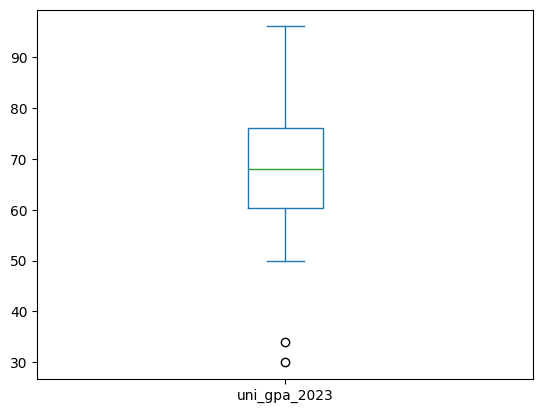

In [61]:
# Outlier Detection and Cleaning

filled_df.uni_gpa_2023.plot(kind = "box")

<Axes: ylabel='Density'>

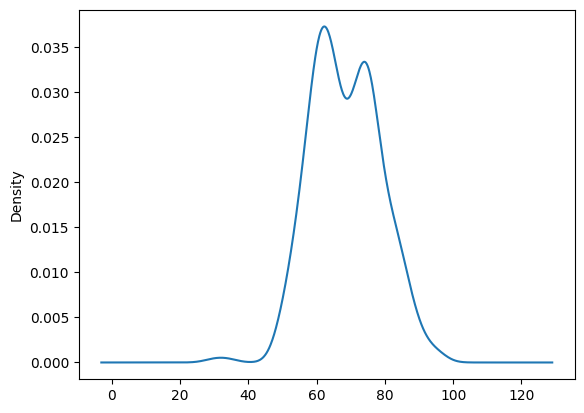

In [62]:
filled_df.uni_gpa_2023.plot.kde()

In [67]:
def filter_outlier_with_IQR(series : pd.Series) -> pd.Series:
    """_summary_"""
    
    IQR = series.quantile(0.75) - series.quantile(0.25)
    max_val = series.quantile(0.75) + (1.5 * IQR)
    min_val = series.quantile(0.25) - (1.5 * IQR)
    
    outlier_filter_mask = (series <= max_val)  & (series >= min_val)
    
    return outlier_filter_mask

In [71]:
final_df = filled_df[filter_outlier_with_IQR(filled_df.uni_gpa_2023)]